In [1]:
import os
import numpy as np
import scipy.signal as signal
import scipy.ndimage as ndimage
import matplotlib.pyplot as plt
import librosa

## Computing Spectograms

### Functions

In [2]:
def load_audio(file_path, target_sr=22050):
    audio_array, sample_rate = librosa.load(file_path, sr=target_sr)
    return audio_array, sample_rate

In [3]:
def generate_spectrogram(audio_array, sample_rate, window_length=1024, overlap=512):
    frequencies, times, Sxx = signal.spectrogram(
        audio_array, 
        fs=sample_rate, 
        window='hann',
        nperseg=window_length, 
        noverlap=overlap
    )
    # Convert power to dB
    Sxx_db = 10 * np.log10(Sxx + 1e-10) 
    return frequencies, times, Sxx_db

### Testing

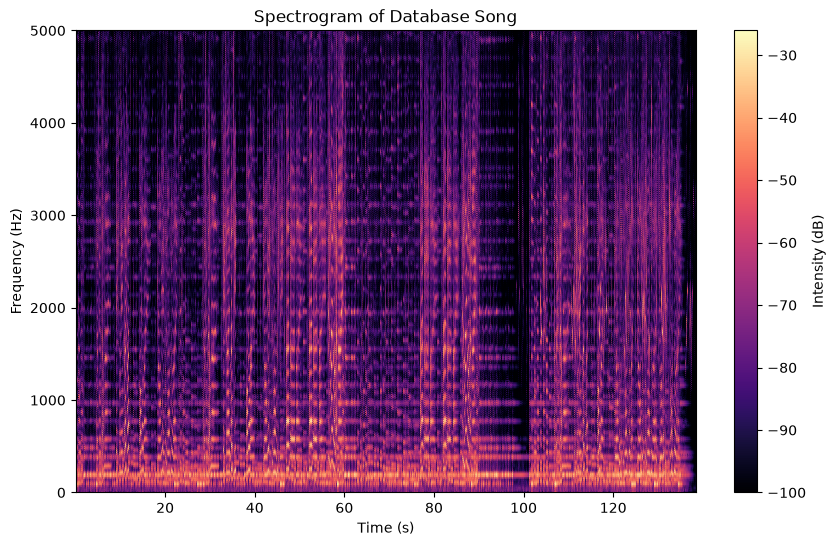

In [4]:
# Define path
test_song_path = r"data\database_songs\Blackbird.mp3"

# Execute
audio, sr = load_audio(test_song_path)
freqs, times, spec_db = generate_spectrogram(audio, sr)

# Plotting
plt.figure(figsize=(10, 6))
plt.pcolormesh(times, freqs, spec_db, shading='gouraud', cmap='magma')
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (s)')
plt.title('Spectrogram of Database Song')
plt.colorbar(label='Intensity (dB)')
plt.ylim(0, 5000)
plt.show()

## Peak Extraction

In [5]:
def extract_peaks(spectrogram_db, freqs, times, neighborhood_size=20, amplitude_threshold=-40):
    # Apply a max filter to find local peaks
    local_max = ndimage.maximum_filter(spectrogram_db, size=neighborhood_size)

    # Peak: Value = Local Max
    peak_mask = (spectrogram_db == local_max)

    # Filter background noise (peaks must be louder than threshold)
    threshold_mask = (spectrogram_db > amplitude_threshold)

    # Combine masks
    valid_peaks = peak_mask & threshold_mask

    # Extract coordinates
    freq_indices, time_indices = np.where(valid_peaks)

    # Map indices to actual freq & time
    peak_freqs = freqs[freq_indices]
    peak_times = times[time_indices]

    return peak_times, peak_freqs

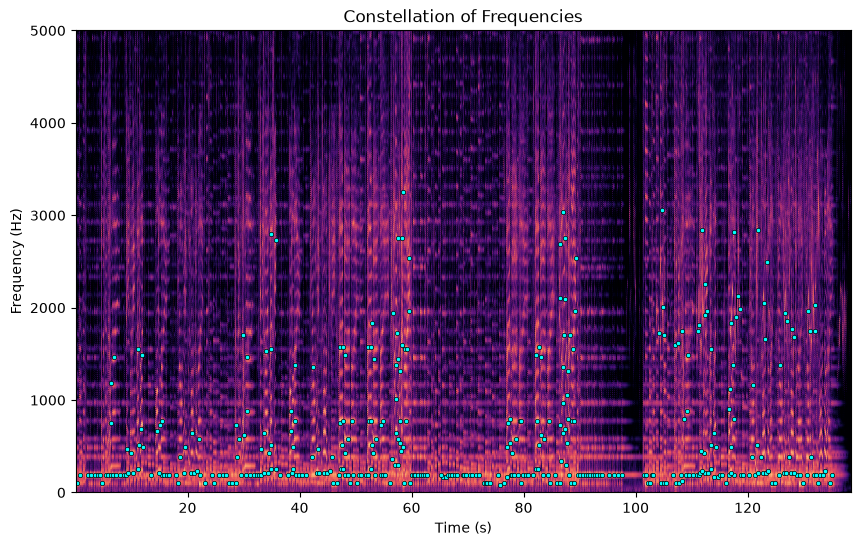

In [6]:
p_times, p_freqs = extract_peaks(spec_db, freqs, times)

plt.figure(figsize=(10, 6))
# Plot spectrogram as background
plt.pcolormesh(times, freqs, spec_db, shading='gouraud', cmap='magma', alpha=0.5)
# Overlay peaks
plt.scatter(p_times, p_freqs, color='cyan', s=10, edgecolors='black', linewidth=0.5)
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (s)')
plt.title('Constellation of Frequencies')
plt.ylim(0, 5000)
plt.show()

## Generating Hashes

In [7]:
def generate_hashes(peak_times, peak_freqs, fan_value=15):
    hashes = []
    num_peaks = len(peak_times)

    for i in range(num_peaks):
        for j in range(1, fan_value):
            if (i + j) < num_peaks:
                freq1 = peak_freqs[i]
                freq2 = peak_freqs[i + j]
                time1 = peak_times[i]
                time2 = peak_times[i + j]

                time_delta = time2 - time1

                # Creating hash tuple
                hash_tuple = (freq1, freq2, round(time_delta, 3))

                # Store hash & time of occurrence
                hashes.append((hash_tuple, time1))

    return hashes

## Indexing the Database

In [11]:
import os
import pickle

def build_database(database_dir):
    # The dictionary will map: hash_tuple -> list of (song_name, absolute_time)
    song_database = {} 

    for filename in os.listdir(database_dir):
        if filename.endswith(".mp3") or filename.endswith(".wav"):
            song_name = os.path.splitext(filename)[0] # Extract name strictly without extension
            file_path = os.path.join(database_dir, filename)

            print(f"Indexing {song_name}...")

            # Execute the pipeline
            audio, sr = load_audio(file_path)
            freqs, times, spec_db = generate_spectrogram(audio, sr)
            p_times, p_freqs = extract_peaks(spec_db, freqs, times)
            hashes = generate_hashes(p_times, p_freqs)

            # Populate the dictionary
            for hash_tuple, time_offset in hashes:
                if hash_tuple not in song_database:
                    song_database[hash_tuple] = []
                song_database[hash_tuple].append((song_name, time_offset))

    # Save to disk
    with open('song_database.pkl', 'wb') as f:
        pickle.dump(song_database, f)

    print("Database fully built and saved as song_database.pkl")
    return song_database

# Execute the build
db_path = r"data\database_songs"
song_database = build_database(db_path)

Indexing A Day In The Life...
Indexing A Hard Day_s Night...
Indexing Across The Universe...
Indexing Back In The U.S.S.R....
Indexing Blackbird...
Indexing Bohemian Rhapsody...
Indexing Can_t Buy Me Love...
Indexing Crazy Little Thing Called Love...
Indexing Day Tripper...
Indexing Don_t Stop Me Now...
Indexing Drive My Car...
Indexing Eight Days A Week...
Indexing Eleanor Rigby...
Indexing Get Back...
Indexing Hello, Goodbye...
Indexing Help!...
Indexing Helter Skelter...
Indexing Hey Jude...
Indexing I Am The Walrus...
Indexing I Saw Her Standing There...
Indexing I Want It All...
Indexing I Want To Hold Your Hand...
Indexing In My Life...
Indexing I_ll Follow The Sun...
Indexing I_ve Got A Feeling...
Indexing Killer Queen...
Indexing Let It Be...
Indexing Love Me Do...
Indexing Lucy In The Sky With Diamonds...
Indexing Never Gonna Give You Up...
Indexing Norwegian Wood (This Bird Has Flown)...
Indexing Penny Lane...
Indexing Radio Ga Ga...
Indexing Revolution...
Indexing Sgt. Peppe

## Matching

### Function

In [9]:
from collections import Counter

def match_query(query_path, song_database):
    # Process the query clip
    audio, sr = load_audio(query_path)
    freqs, times, spec_db = generate_spectrogram(audio, sr)
    p_times, p_freqs = extract_peaks(spec_db, freqs, times)
    query_hashes = generate_hashes(p_times, p_freqs)
    
    total_query_hashes = len(query_hashes)
    
    # Edge case: If the query is completely silent or lacks peaks
    if total_query_hashes == 0:
        return None, 0.0

    # Dictionary to track time offsets per song
    matches_per_song = {}
    
    # Compare hashes against the database
    for q_hash, q_time in query_hashes:
        if q_hash in song_database:
            for db_song, db_time in song_database[q_hash]:
                
                offset = round(db_time - q_time, 3)
                
                if db_song not in matches_per_song:
                    matches_per_song[db_song] = []
                matches_per_song[db_song].append(offset)
    
    # Analyze the offset histogram
    best_match = None
    max_aligned_count = 0
    
    for song, offsets in matches_per_song.items():
        if offsets:
            most_common_offset, count = Counter(offsets).most_common(1)[0]
            
            if count > max_aligned_count:
                max_aligned_count = count
                best_match = song
                
    # Calculate normalized confidence score (0 to 1)
    confidence = max_aligned_count / total_query_hashes
                
    return best_match, confidence

### Testing

In [12]:
query_clip_path = r"data\query_clips\I Want It All_noise_0.5.wav"

recognized_song, confidence = match_query(query_clip_path, song_database)
print(f"Target file: {query_clip_path}")
print(f"Identified Song: {recognized_song}")
print(f"Match Alignments (Confidence): {confidence}")

Target file: data\query_clips\I Want It All_noise_0.5.wav
Identified Song: I Want It All
Match Alignments (Confidence): 0.7243010752688172


## Experiments

### 1. Window Length Analysis

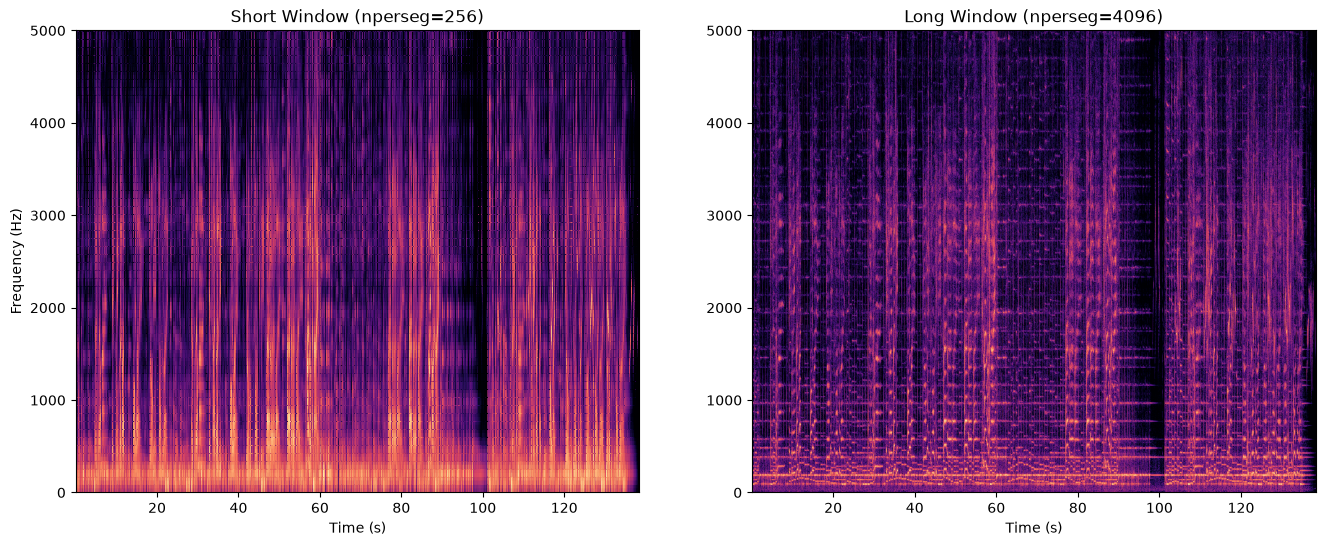

In [13]:
def plot_window_comparison(audio_path):
    audio, sr = load_audio(audio_path)
    
    # Short Window: High time resolution, poor frequency resolution
    short_window = 256
    f_short, t_short, Sxx_short = generate_spectrogram(audio, sr, window_length=short_window, overlap=short_window//2)
    
    # Long Window: High frequency resolution, poor time resolution
    long_window = 4096
    f_long, t_long, Sxx_long = generate_spectrogram(audio, sr, window_length=long_window, overlap=long_window//2)
    
    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    ax1.pcolormesh(t_short, f_short, Sxx_short, shading='gouraud', cmap='magma')
    ax1.set_title(f'Short Window (nperseg={short_window})')
    ax1.set_ylabel('Frequency (Hz)')
    ax1.set_xlabel('Time (s)')
    ax1.set_ylim(0, 5000)
    
    ax2.pcolormesh(t_long, f_long, Sxx_long, shading='gouraud', cmap='magma')
    ax2.set_title(f'Long Window (nperseg={long_window})')
    ax2.set_xlabel('Time (s)')
    ax2.set_ylim(0, 5000)
    
    plt.show()

# Execute
plot_window_comparison(r"data\database_songs\Blackbird.mp3")

### 2. Single Peak Matching

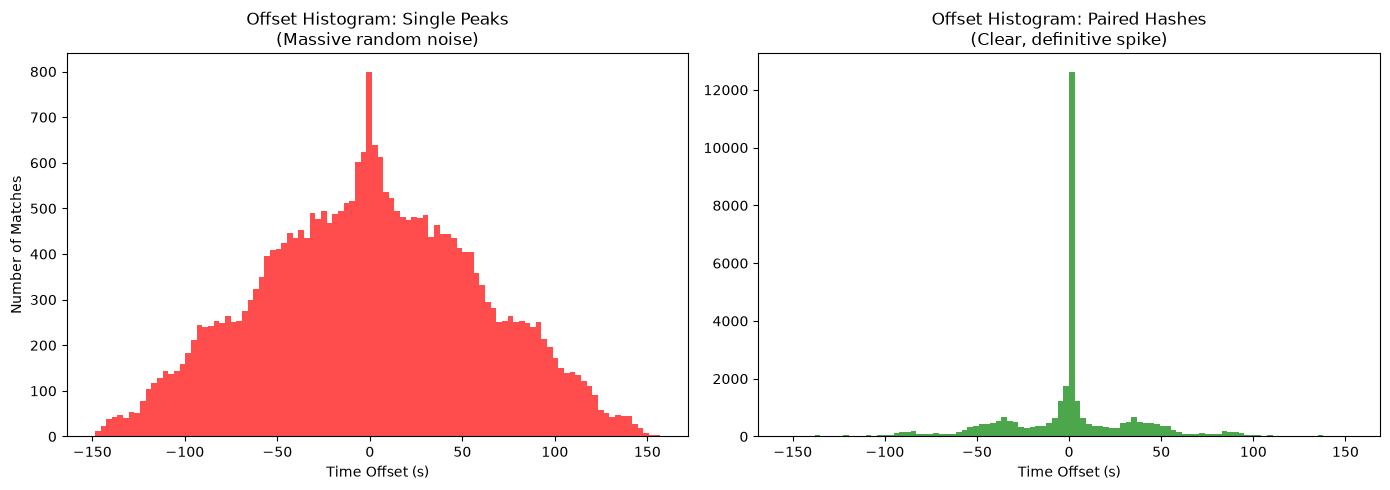

In [23]:
from collections import Counter

def comparison_test(clean_path, noisy_path):
    # Load and process both files
    audio_db, sr = load_audio(clean_path)
    audio_q, _ = load_audio(noisy_path)
    
    f_db, t_db, spec_db = generate_spectrogram(audio_db, sr)
    f_q, t_q, spec_q = generate_spectrogram(audio_q, sr)
    
    # Extract peaks
    p_t_db, p_f_db = extract_peaks(spec_db, f_db, t_db)
    p_t_q, p_f_q = extract_peaks(spec_q, f_q, t_q)
    
    # Single Peaks
    single_offsets = []
    # Limit to first 200 query peaks to force termination
    for i in range(min(200, len(p_f_q))):
        q_freq = p_f_q[i]
        q_time = p_t_q[i]
        
        # Find everywhere this exact frequency occurs in the database song
        matching_indices = np.where(p_f_db == q_freq)[0]
        for idx in matching_indices:
            db_time = p_t_db[idx]
            single_offsets.append(round(db_time - q_time, 2))
            
    # Paired Hashes
    paired_offsets = []
    db_hashes = generate_hashes(p_t_db, p_f_db)
    q_hashes = generate_hashes(p_t_q, p_f_q)
    
    # Convert db hashes to a fast-lookup dictionary for this single song
    db_hash_dict = {}
    for h_tuple, time in db_hashes:
        if h_tuple not in db_hash_dict:
            db_hash_dict[h_tuple] = []
        db_hash_dict[h_tuple].append(time)
        
    for q_tuple, q_time in q_hashes:
        if q_tuple in db_hash_dict:
            for db_time in db_hash_dict[q_tuple]:
                paired_offsets.append(round(db_time - q_time, 2))

    # Visualisation
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.hist(single_offsets, bins=100, color='red', alpha=0.7)
    ax1.set_title("Offset Histogram: Single Peaks\n(Massive random noise)")
    ax1.set_xlabel("Time Offset (s)")
    ax1.set_ylabel("Number of Matches")
    
    ax2.hist(paired_offsets, bins=100, color='green', alpha=0.7)
    ax2.set_title("Offset Histogram: Paired Hashes\n(Clear, definitive spike)")
    ax2.set_xlabel("Time Offset (s)")
    
    plt.tight_layout()
    plt.show()

# Execute
clean_song = r"data\database_songs\Day Tripper.mp3"
noisy_clip = r"data\query_clips\Day Tripper_noise_0.2.wav"
comparison_test(clean_song, noisy_clip)

### 3. Noise Tolerance

Evaluating noise thresholds for base file: In My Life
Noise 1.0% | Match: In My Life | Confidence: 0.9904
Noise 5.0% | Match: In My Life | Confidence: 0.9658
Noise 10.0% | Match: In My Life | Confidence: 0.9528
Noise 20.0% | Match: In My Life | Confidence: 0.8870
Noise 50.0% | Match: In My Life | Confidence: 0.7249


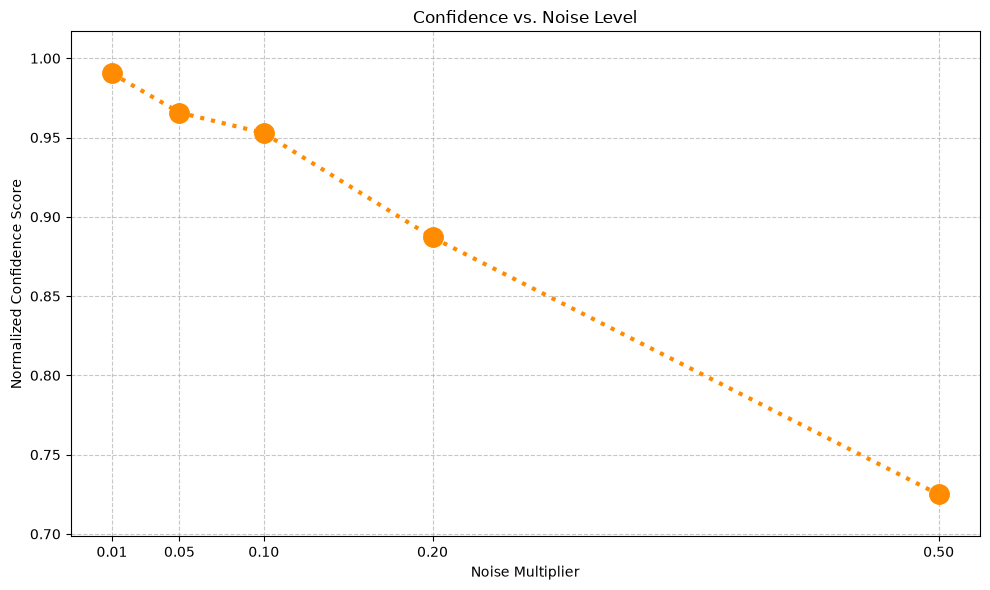

In [28]:
def evaluate_noise_thresholds(test_folder, base_filename, song_database):
    noise_levels = [0.01, 0.05, 0.1, 0.2, 0.5]
    confidence_scores = []
    evaluated_levels = [] # Tracks valid levels in case a file is missing
    
    print(f"Evaluating noise thresholds for base file: {base_filename}")
    
    for level in noise_levels:
        target_file = f"{base_filename}_noise_{level}.wav"
        file_path = os.path.join(test_folder, target_file)
        
        if os.path.exists(file_path):
            match, confidence = match_query(file_path, song_database)
            print(f"Noise {level*100}% | Match: {match} | Confidence: {confidence:.4f}")
            
            # Store data for plotting
            confidence_scores.append(confidence)
            evaluated_levels.append(level)
        else:
            print(f"File missing: {target_file}")
            
    # Line Graph
    if confidence_scores:
        plt.figure(figsize=(10, 6))
        
        plt.plot(evaluated_levels, confidence_scores, marker='o', linestyle=':', color='darkorange', linewidth=3, markersize=14)
        
        plt.title('Confidence vs. Noise Level')
        plt.xlabel('Noise Multiplier')
        plt.ylabel('Normalized Confidence Score')
        
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.xticks(noise_levels)
        
        min_conf = min(confidence_scores)
        max_conf = max(confidence_scores)
        
        padding = (max_conf - min_conf) * 0.1
        if padding == 0:
            padding = 0.05
            
        plt.ylim(min_conf - padding, max_conf + padding)
        
        plt.tight_layout()
        plt.show()
    else:
        print("No valid data points found to generate the plot.")

# Execute
evaluate_noise_thresholds(r"data\query_clips", "In My Life", song_database)

### 4. Pitch Shift & Time Stretch

In [26]:
import soundfile as sf

def generate_adversarial_clips(clean_path, output_dir):
    audio, sr = librosa.load(clean_path, sr=22050)
    base_name = os.path.splitext(os.path.basename(clean_path))[0]
    
    # Pitch Shift (Shift up by 2 semitones)
    pitch_shifted = librosa.effects.pitch_shift(y=audio, sr=sr, n_steps=2)
    pitch_path = os.path.join(output_dir, f"{base_name}_pitch_shifted.wav")
    sf.write(pitch_path, pitch_shifted, sr)
    
    # Time Stretch (Speed up by 10%)
    time_stretched = librosa.effects.time_stretch(y=audio, rate=1.1)
    time_path = os.path.join(output_dir, f"{base_name}_time_stretched.wav")
    sf.write(time_path, time_stretched, sr)
    
    return pitch_path, time_path

# Execute
clean_source = r"data\database_songs\Under Pressure.mp3"
p_path, t_path = generate_adversarial_clips(clean_source, r"data")

print("Pitch Shifted Match:", match_query(p_path, song_database))
print("Time Stretched Match:", match_query(t_path, song_database))

Pitch Shifted Match: ('Under Pressure', 0.008423669129324036)
Time Stretched Match: ('Under Pressure', 0.0016127663186486715)
